<div align="center">
<p align="center" style="width: 100%;">
    <img src="https://raw.githubusercontent.com/vlm-run/.github/refs/heads/main/profile/assets/vlm-black.svg" alt="VLM Run Logo" width="80" style="margin-bottom: -5px; color: #2e3138; vertical-align: middle; padding-right: 5px;"><br>
</p>
<p align="center"><a href="https://vlm.run"><b>Website</b></a> | <a href="https://docs.vlm.run/"><b>API Docs</b></a> | <a href="https://vlm.run/blog"><b>Blog</b></a> | <a href="https://discord.gg/AMApC2UzVY"><b>Discord</b></a>
</p>
</div>

# Migrating to Orion-2: Requests → Executions

The migration is essentially one change: **the function you call.** Your API key and the document stay the same. What changes is the method that runs the extraction, and how each surface is configured (a **domain** on Requests, a **skill** on Executions).

| | Function to call |
|---|---|
| **Old way (Requests)** | `client.document.generate(...)` |
| **New way (Executions)** | `client.agent.execute(...)` |

We run the same handwritten physician referral form through both surfaces, with grounding and confidence on each side, and visualize the results.

**Docs:** [Code Execution](https://docs.vlm.run/agents/code-execution), [Ways to Use VLM Run](https://docs.vlm.run/ways-to-use-vlm-run), [Requests](https://docs.vlm.run/skills/usage/generation), [Executions](https://docs.vlm.run/skills/usage/agent)


---
## ⚙️ 1. Setup

Install the VLM Run SDK, plus `pypdfium2` (used by the SDK's `pdf_images` helper to render the pages).


In [1]:
!pip install vlmrun --upgrade --quiet
!pip install pypdfium2 --quiet


## 🔑 2. Load your API key

Add your `VLMRUN_API_KEY` to the Colab **Secrets** tab (🔑 icon, left sidebar), then load it below.


In [2]:
import os

try:
    from google.colab import userdata
    VLMRUN_API_KEY = userdata.get("VLMRUN_API_KEY")
except (ImportError, Exception):
    import getpass
    VLMRUN_API_KEY = os.getenv("VLMRUN_API_KEY") or getpass.getpass("Enter your VLM Run API key: ")

assert VLMRUN_API_KEY, "Missing VLMRUN_API_KEY in environment or Colab Secrets."
print("✅ API key loaded")


✅ API key loaded


## 🧩 3. Domain vs. skill

Each surface is configured differently:

- **Requests** use a domain (here `healthcare.patient-referral`), with grounding and confidence set on the call via `config={"grounding": True, "confidence": True}`.
- **Executions** use the `grounded-document-extraction` skill, whose pipeline already runs `vlmrun.document.extract(..., grounding=True, confidence=True)`, so grounding and confidence are built in.

Both return structured, grounded JSON.


In [3]:
from vlmrun.client.types import AgentSkill

# Old way (Requests): pre-defined domain; grounding/confidence passed on the call
REQUESTS_DOMAIN = "healthcare.patient-referral"  # or your custom domain / json_schema

# New way (Orion-2 Executions): grounded-document-extraction skill; grounding/confidence baked in
EXECUTIONS_SKILL = AgentSkill(
    skill_name="grounded-document-extraction",
    skill_version="20260720-b19b53d9",
)

print("Requests domain: ", REQUESTS_DOMAIN)
print("Executions skill:", EXECUTIONS_SKILL.skill_name, EXECUTIONS_SKILL.skill_version)


Requests domain:  healthcare.patient-referral
Executions skill: grounded-document-extraction 20260720-b19b53d9


## 📄 4. The document: handwritten physician referral form

Download the form and preview page 1. The rasterized pages (`pdf_pages`) are reused later for the bounding-box overlays.


Downloaded handwritten-patient-referral.pdf | 1 page(s)



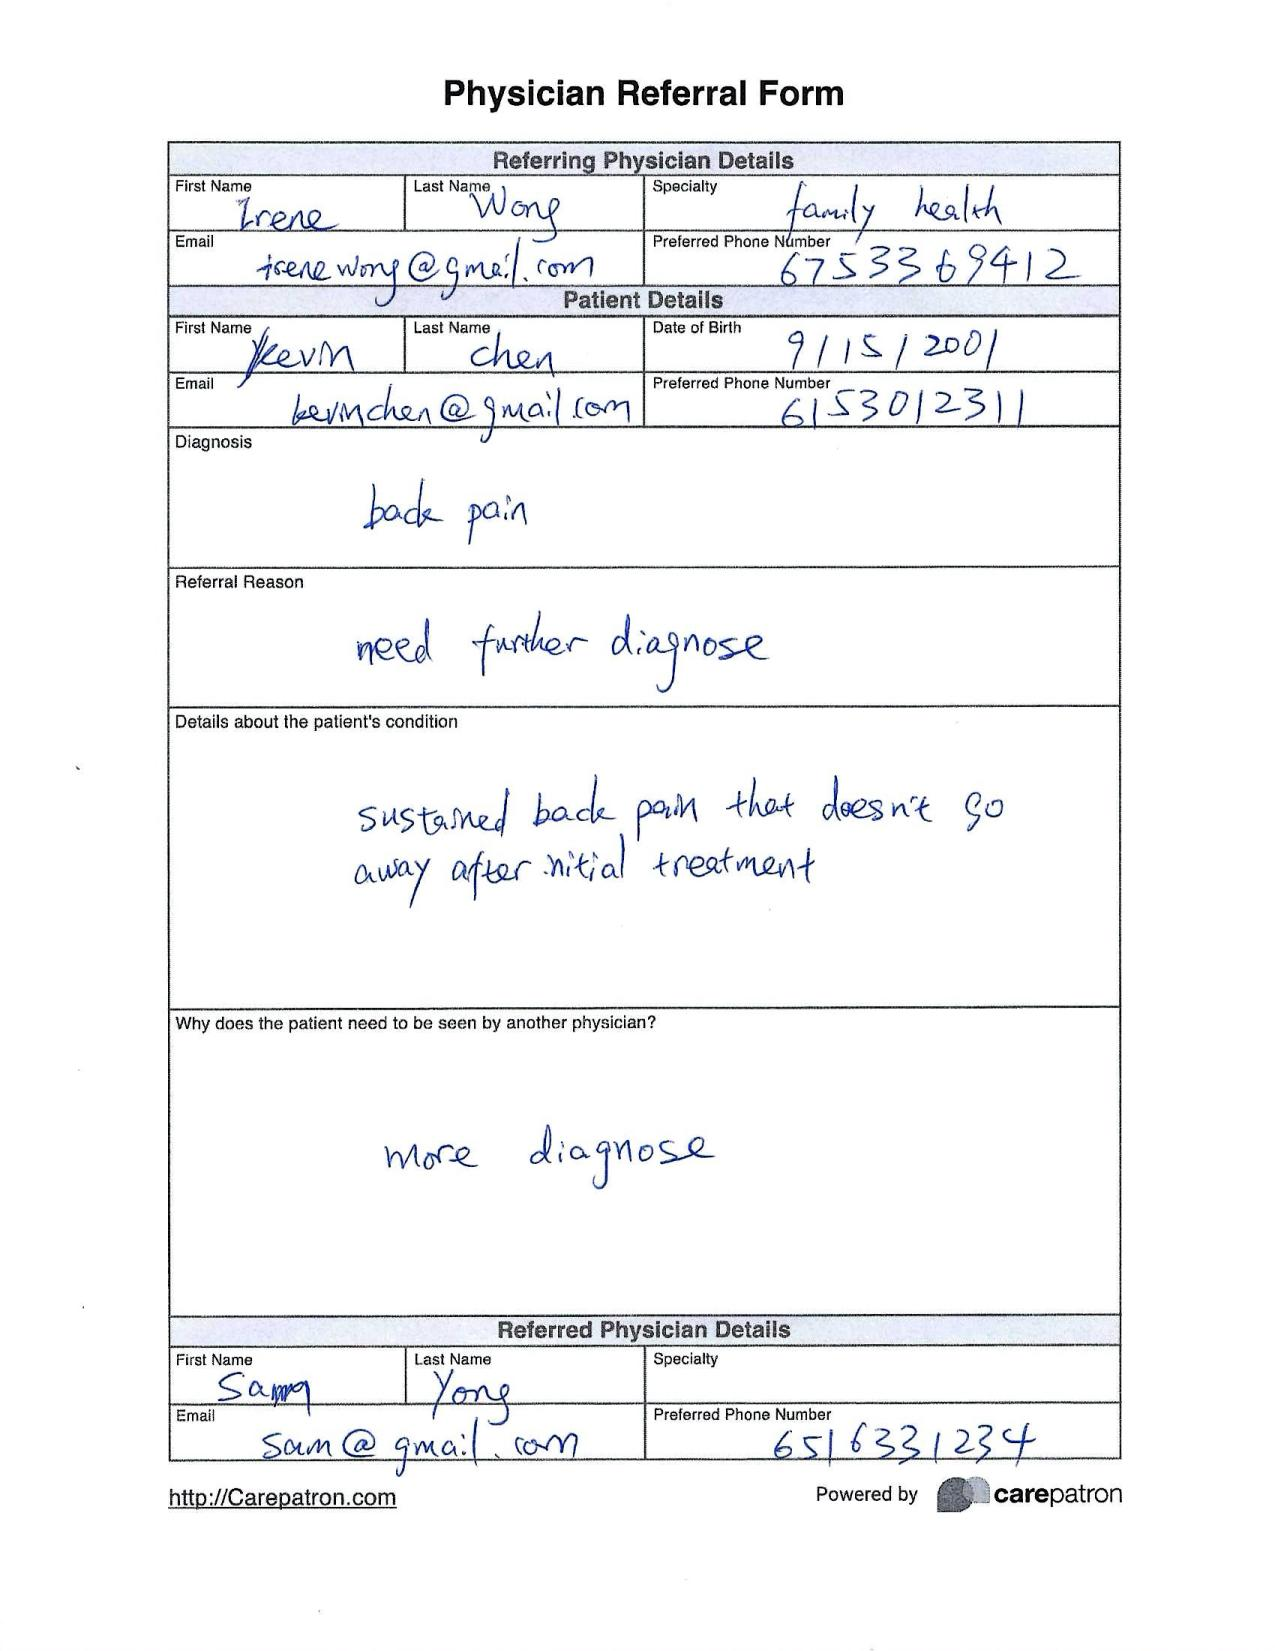

In [4]:
import base64, requests
from io import BytesIO
from pathlib import Path
from IPython.display import HTML, display
from vlmrun.common.pdf import pdf_images  # SDK helper (pypdfium2 under the hood)


def show_image(img, caption="", width=560):
    """Show a PIL image inline, capped at `width` px so it fits nicely in Colab."""
    buf = BytesIO()
    img.convert("RGB").save(buf, format="JPEG")
    b64 = base64.b64encode(buf.getvalue()).decode()
    tag = (f"<img src='data:image/jpeg;base64,{b64}' "
           f"style='max-width:{width}px; border:1px solid #eee; border-radius:6px'>")
    if caption:
        tag = (f"<div style='text-align:center'>{tag}"
               f"<div style='font-size:12px; color:#666; margin-top:4px'>{caption}</div></div>")
    display(HTML(tag))


REFERRAL_URL = "https://storage.googleapis.com/vlm-data-public-prod/hub/examples/healthcare.patient-referral/handwritten-patient-referral.pdf"
PDF_PATH = Path("/content/handwritten-patient-referral.pdf")
PDF_PATH.write_bytes(requests.get(REFERRAL_URL).content)

pdf_pages = list(pdf_images(PDF_PATH, dpi=150))
print(f"Downloaded {PDF_PATH.name} | {len(pdf_pages)} page(s)")
show_image(pdf_pages[0].image, caption="Physician referral form (page 1)", width=560)


---
## 🕰️ 5. The old way: Requests

Set up the client (hosted at `api.vlm.run`, the SDK default). The same client handles both surfaces.


In [5]:
from vlmrun.client import VLMRun

# One default client (api.vlm.run) handles both surfaces
client = VLMRun(api_key=VLMRUN_API_KEY)
print("✅ Client ready → api.vlm.run")


✅ Client ready → api.vlm.run


Call `client.document.generate` with the domain, and turn on grounding and confidence so every field comes back with bounding boxes and scores. Requests run in batch mode: `generate` returns a job, and `predictions.wait` blocks until it is ready. The result lives on `response.response`.


In [6]:
from vlmrun.client.types import GenerationConfig

request_response = client.document.generate(
    file=PDF_PATH,
    domain=REQUESTS_DOMAIN,  # healthcare.patient-referral, or a custom domain / json_schema
    config=GenerationConfig(
        grounding=True,
        confidence=True,
        detail="hi",
    ),
)
print("✅ Extraction complete | status:", request_response.status)

# If the job is still pending (batch mode), wait for the prediction
if request_response.status != "completed":
    request_response = client.predictions.wait(request_response.id, timeout=300)
    print("✅ Status:", request_response.status)


✅ Extraction complete | status: completed


### 🧾 Raw JSON response

Structured fields plus per-field `_metadata` (bounding boxes and confidence scores).


In [7]:
import json
from IPython.display import JSON

request_result = request_response.model_dump()
request_data = request_result.get("response", request_result)
JSON(request_data) if request_data else print("None")


<IPython.core.display.JSON object>

### 🖼️ Visualize the bounding boxes

The helper below walks the response for `_metadata.bboxes`, draws each box on the page, and labels it with the field's final extracted value (not the raw per-box OCR text). Visualization is not the focus of this notebook, so feel free to collapse the helper cell.


In [8]:
# Visualization helpers (draw grounding boxes on the page). Not the focus of this
# notebook: collapse this cell if you like.
from difflib import SequenceMatcher
from PIL import ImageDraw, ImageFont


def _font(size):
    for p in ("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
              "/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf"):
        try:
            return ImageFont.truetype(p, size)
        except Exception:
            pass
    try:
        return ImageFont.load_default(size=size)
    except TypeError:
        return ImageFont.load_default()


def _align(value, chunks):
    """Split a field's final value across its boxes (fuzzy), so each box shows its
    own slice of the value. Falls back to the raw OCR text only if there is no value."""
    if value is None:
        return [str(c or "") for c in chunks]
    final = str(value)
    if len(chunks) <= 1:
        return [final]
    low, anchors = final.lower(), []
    for c in chunks:
        cs = str(c or "").lower().strip()
        m = SequenceMatcher(None, low, cs, autojunk=False).find_longest_match(0, len(low), 0, len(cs)) if cs else None
        if not cs or m.size == 0:
            anchors = None
            break
        center, half = m.a + m.size // 2, max(len(cs) // 2, m.size // 2)
        anchors.append((max(0, center - half), min(len(final), center + half)))
    if anchors is None:                                  # even split fallback
        step = len(final) / len(chunks)
        return [final[int(i * step):int((i + 1) * step)].strip() for i in range(len(chunks))]
    order = sorted(range(len(anchors)), key=lambda i: anchors[i][0])
    sa = [anchors[i] for i in order]
    bounds = [0] + [(sa[i][1] + sa[i + 1][0]) // 2 for i in range(len(sa) - 1)] + [len(final)]

    def snap(idx):
        if idx <= 0 or idx >= len(final):
            return idx
        l, r = final.rfind(" ", 0, idx), final.find(" ", idx)
        if l == -1 and r == -1:
            return idx
        if l == -1:
            return r
        if r == -1:
            return l
        return l if idx - l <= r - idx else r

    bounds = [snap(b) for b in bounds]
    ordered = [final[bounds[i]:bounds[i + 1]].strip() for i in range(len(bounds) - 1)]
    out = [""] * len(chunks)
    for si, oi in enumerate(order):
        out[oi] = ordered[si]
    return out


def collect_bboxes(obj, path=""):
    """(field, page, xywh, label, value, confidence) for every grounded box.

    `value` is the final extracted value from the response (the sibling field of
    `<field>_metadata`), and `label` is that value drawn on the box, not the raw
    per-box OCR `content`. `confidence` is the field-level "hi"/"med"/"lo" score.
    """
    out = []
    if isinstance(obj, dict):
        for k, v in obj.items():
            if k.endswith("_metadata") and isinstance(v, dict) and v.get("bboxes"):
                field = k[:-len("_metadata")]
                value = obj.get(field)                     # final extracted value (sibling)
                conf = v.get("confidence")                 # field-level confidence
                items = [it for it in v["bboxes"]
                         if isinstance(it, dict) and (it.get("bbox") or {}).get("xywh")]
                labels = _align(value, [it.get("content", "") for it in items])
                fpath = f"{path}.{field}" if path else field
                for it, label in zip(items, labels):
                    out.append((fpath, it.get("page", 0), it["bbox"]["xywh"], label, value, conf))
            elif not k.endswith("_metadata"):
                out += collect_bboxes(v, f"{path}.{k}" if path else k)
    elif isinstance(obj, list):
        for i, v in enumerate(obj):
            out += collect_bboxes(v, f"{path}[{i}]")
    return out


def render_bboxes(bboxes, pages, width=560):
    """Draw the boxes on each rasterized page and show it (capped at `width`)."""
    for page in pages:
        idx = page.page_number
        boxes = [b for b in bboxes if b[1] == idx] or (bboxes if len(pages) == 1 else [])
        img = page.image.copy().convert("RGB")
        draw = ImageDraw.Draw(img)
        W, H = img.size
        font = _font(26)
        for field, _pg, (x, y, w, h), label, _value, _conf in boxes:
            x0, y0, x1, y1 = int(x * W), int(y * H), int((x + w) * W), int((y + h) * H)
            draw.rectangle([x0, y0, x1, y1], outline="red", width=3)
            text = str(label) if label else field.split(".")[-1]
            ly = max(0, y0 - 30)
            draw.rectangle(draw.textbbox((x0, ly), text, font=font), fill="red")
            draw.text((x0, ly), text, fill="white", font=font)
        show_image(img, caption=f"Page {idx + 1} ({len(boxes)} boxes)", width=width)


print("Visualization helpers loaded.")

Visualization helpers loaded.


Found 39 grounded boxes



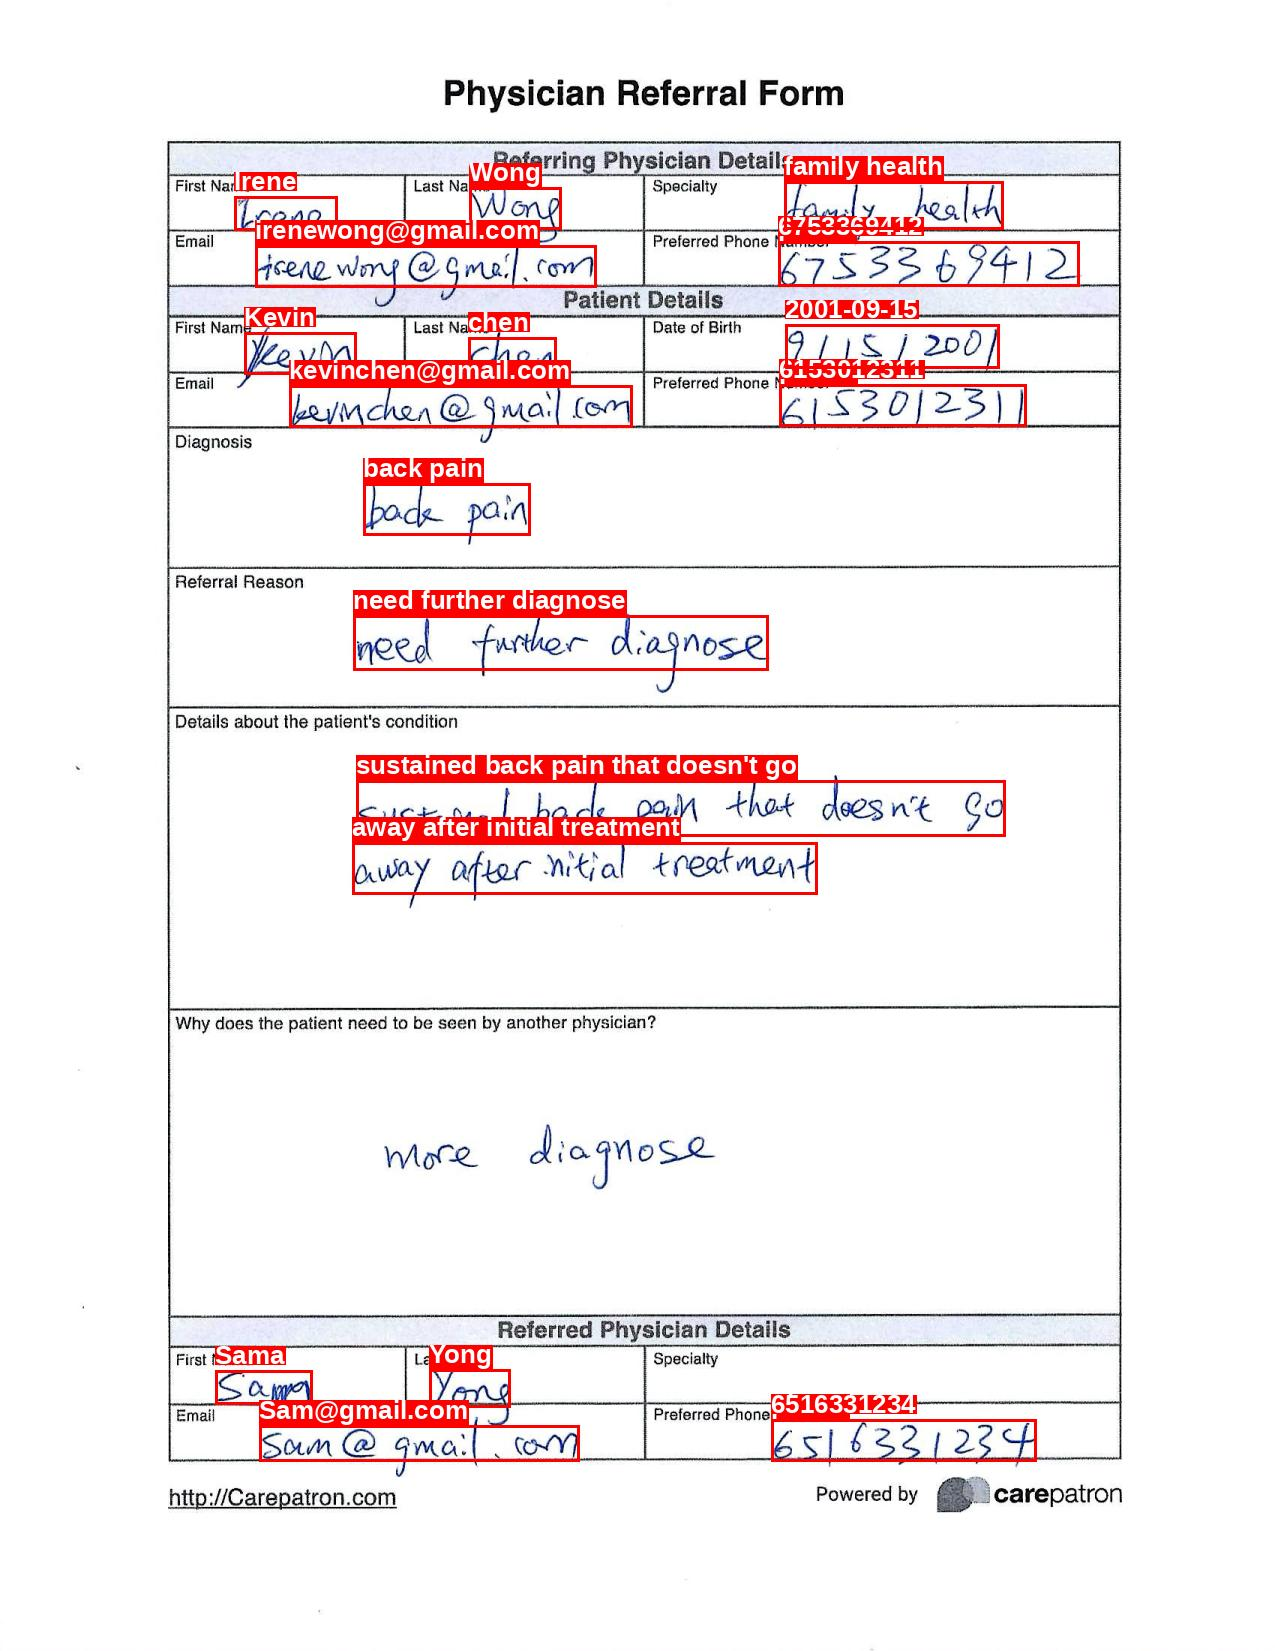

In [9]:
request_bboxes = collect_bboxes(request_data)
print(f"Found {len(request_bboxes)} grounded boxes")
render_bboxes(request_bboxes, pdf_pages)


### 📋 What was extracted

A readable table of each grounded field, its value, and confidence.


In [10]:
import re
import pandas as pd
from IPython.display import display


def show_extracted(bboxes):
    """Readable summary: one row per field with its final value and confidence."""
    rows, seen = [], set()
    for field, _page, _xywh, _label, value, conf in bboxes:
        if field in seen:
            continue
        seen.add(field)
        name = re.sub(r"^(?:[^.\[]*\[\d+\]\.)+", "", field)  # drop leading list index
        rows.append({"Field": name, "Value": "" if value is None else str(value), "Confidence": conf})
    df = pd.DataFrame(rows, columns=["Field", "Value", "Confidence"])
    return df.style.hide(axis="index").set_table_styles([
        {"selector": "th, td", "props": [("text-align", "left"), ("padding", "6px 14px"), ("font-size", "13px")]},
        {"selector": "thead th", "props": [("background", "#f1f3f4"), ("font-weight", "600")]},
    ])


display(show_extracted(request_bboxes))

Field,Value,Confidence
patient.name.first_name,Kevin,hi
patient.name.last_name,chen,hi
patient.name.full_name,Kevin chen,hi
patient.contact[0].system,email,hi
patient.contact[0].value,kevinchen@gmail.com,med
patient.contact[1].system,phone,hi
patient.contact[1].value,6153012311,hi
patient.dateOfBirth,2001-09-15,hi
referral.patient.name.first_name,Kevin,hi
referral.patient.name.last_name,chen,hi


---
## ✨ 6. The new way: Orion-2

Same `client`. What changes: the function (`agent.execute`), the model (`vlmrun-orion-2:pro`), and the skill (`grounded-document-extraction`). Because the skill already runs grounding and confidence, you do not pass those flags on the call.

Upload the file via the Files API, then run a batched execution with the skill attached. `executions.wait` blocks until it finishes.


In [11]:
from pydantic import BaseModel, Field
from vlmrun.types import MessageContent
from vlmrun.client.types import AgentExecutionConfig, AgentExecutionResponse


class FileInput(BaseModel):
    file: MessageContent = Field(..., description="The file to process")


# Upload the document via the Files API
uploaded_file = client.files.upload(file=PDF_PATH)
print(f"Uploaded file ID: {uploaded_file.id}")

# Kick off the execution with the grounded-document-extraction skill attached
execution: AgentExecutionResponse = client.agent.execute(
    model="vlmrun-orion-2:pro",
    inputs=FileInput(
        file=MessageContent(type="input_file", file_id=uploaded_file.id),
    ),
    config=AgentExecutionConfig(skills=[EXECUTIONS_SKILL], mode="program"),
    batch=True)
print(f"Execution ID: {execution.id} | status: {execution.status}")


Uploaded file ID: bea05e4d-ffde-4b04-bba3-4266935db70b
Execution ID: ff9aa0e3-c6c1-40ae-89e2-6c28e45c17a9 | status: enqueued


### 🧾 Wait & inspect the response

The skill returns `{"results": [<referral per page>]}` with the same grounded `_metadata.bboxes` inside.


In [12]:
from IPython.display import JSON

execution = client.executions.wait(execution.id, timeout=300)
print("✅ Status:", execution.status)

exec_payload = execution.response or {}
# The response may be the referral object directly, or wrapped as {"results": [...]}
# or {"data": {...}}. collect_bboxes walks any shape, so we keep the whole payload
# and let it find the grounded boxes.
exec_data = exec_payload
JSON(exec_payload) if exec_payload else print("None")


✅ Status: completed


<IPython.core.display.JSON object>

### 🖼️ The same grounding, rendered locally

Grounding is baked into the skill, so the execution payload carries the same `_metadata.bboxes` structure. The renderer from Section 5 works here unchanged.


Found 9 grounded boxes in the execution payload



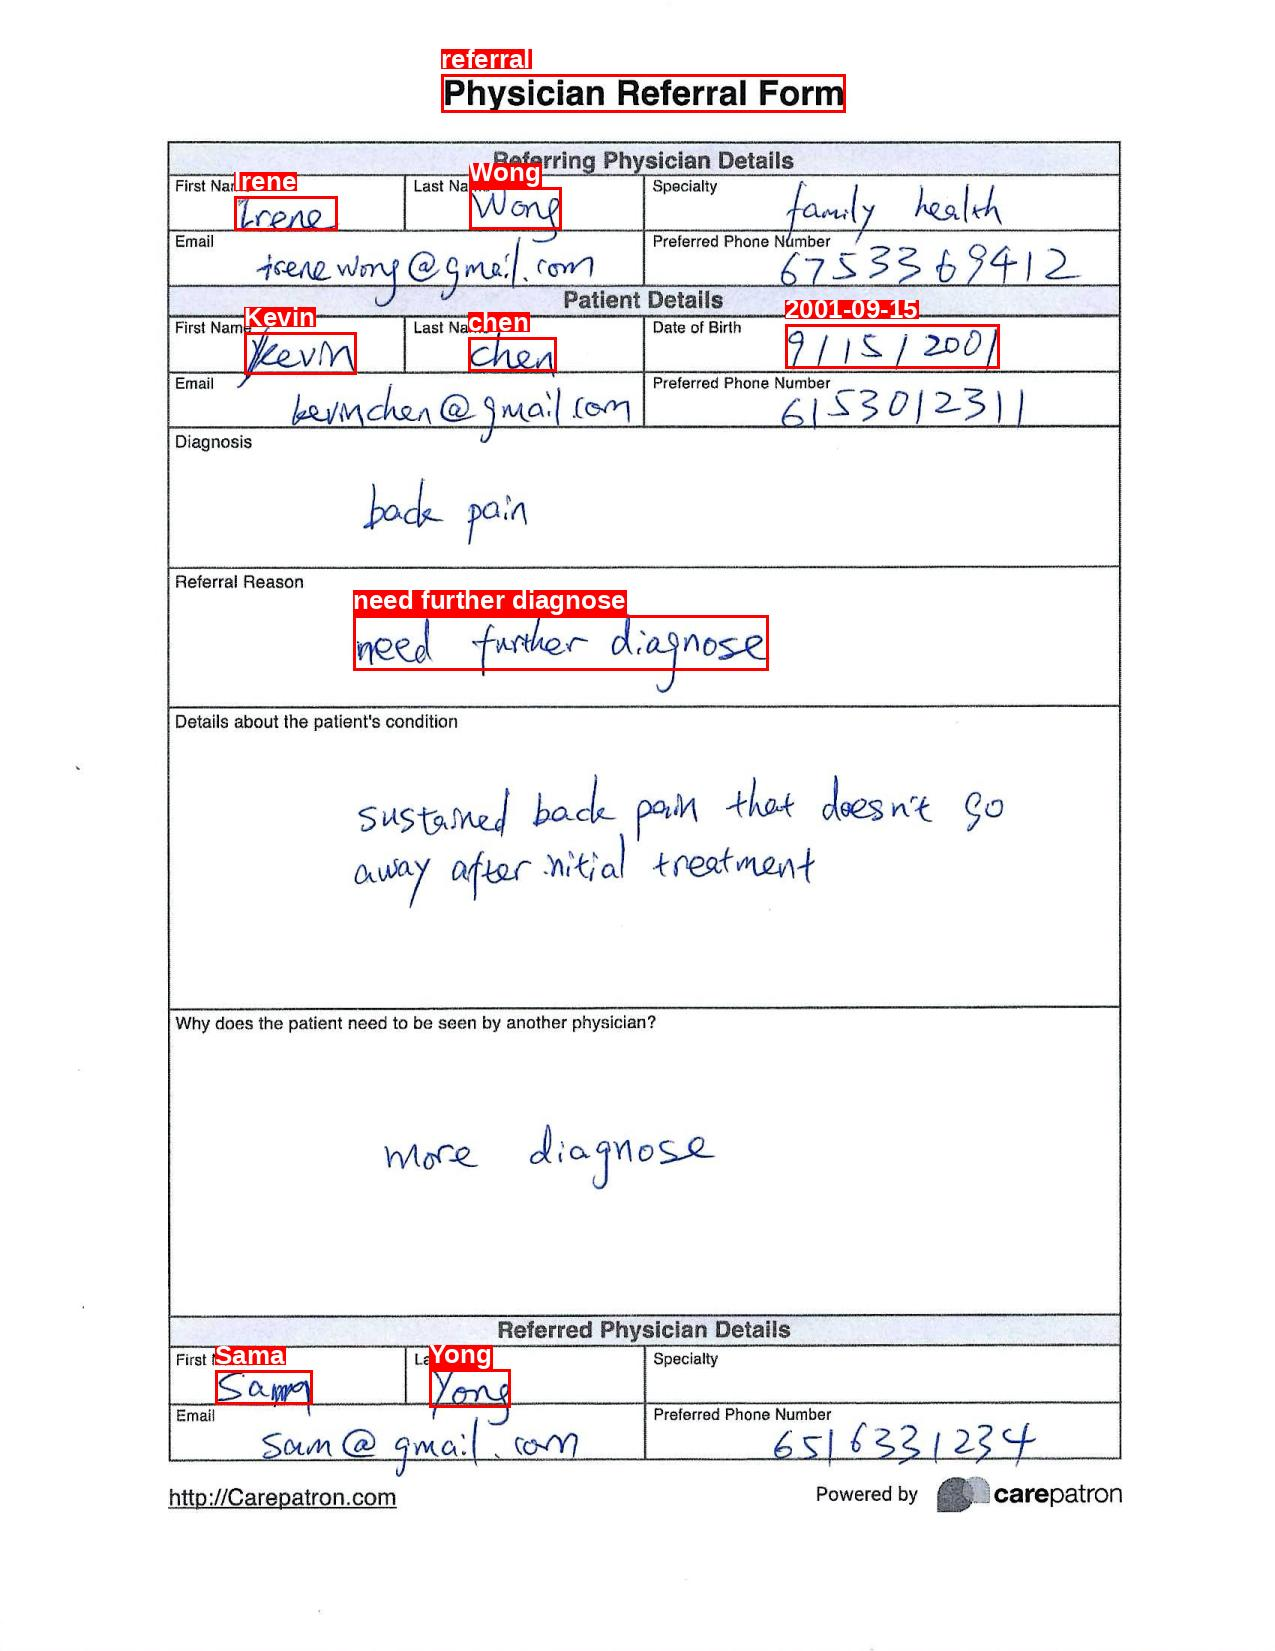

In [13]:
exec_bboxes = collect_bboxes(exec_data)
print(f"Found {len(exec_bboxes)} grounded boxes in the execution payload")

if exec_bboxes:
    render_bboxes(exec_bboxes, pdf_pages)
else:
    print("No bboxes found. Inspect exec_payload above.")


In [14]:
# Readable summary of the same fields (run the cell above first)
if exec_bboxes:
    display(show_extracted(exec_bboxes))


Field,Value,Confidence
patient.givenName,Kevin,hi
patient.familyName,chen,hi
patient.dateOfBirth,2001-09-15,hi
referringProvider.givenName,Irene,hi
referringProvider.familyName,Wong,hi
receivingProvider.givenName,Sama,hi
receivingProvider.familyName,Yong,hi
type,referral,hi
reasonForReferral,need further diagnose,hi


---
## 🧬 7. Extend the skill's schema with your own fields

The `grounded-document-extraction` skill ships with its own default schema (`schema.json`) that its pipeline hands to `vlmrun.document.extract`:

```python
# inside the skill's pipeline.py
schema = json.loads(vlmrun.io.read_file("skills/grounded-document-extraction/schema.json"))
data = await vlmrun.document.extract(doc_path, json_schema=schema, grounding=True, confidence=True)
```

That default captures the core referral fields: `patient` (`givenName`, `familyName`, `dateOfBirth`), `referringProvider`, `receivingProvider`, `reasonForReferral`, `dateOfReferral`, and `schedulingPriority`.

A common customization is to start from that schema and add the fields you also need. Below we replicate the default schema as a Pydantic model and add a few extras that are on the form but missing from the default: contact email and phone for each person, the diagnosis, and the free-text condition details.

On the executions surface you pass `json_schema=Model.model_json_schema()` on `AgentExecutionConfig`. This overrides the skill's built-in `schema.json` (the extraction now targets your shape) while everything else stays the same: same client, same file, same skill.


In [15]:
from typing import Optional
from pydantic import BaseModel, Field

# We mirror the grounded-document-extraction skill’s built-in schema.json
# and then add a few fields. Fields marked "added" are new;
# the rest replicate the skill’s default schema so the diff is obvious.


class Patient(BaseModel):
    # ── from the skill’s default schema ──
    givenName: Optional[str] = Field(..., description="Patient’s first name")
    familyName: Optional[str] = Field(..., description="Patient’s last name")
    dateOfBirth: Optional[str] = Field(None, description="Patient date of birth (YYYY-MM-DD)")
    # ── added ──
    email: Optional[str] = Field(None, description="Patient’s email address")
    phoneNumber: Optional[str] = Field(None, description="Patient’s preferred phone number")


class ReferringProvider(BaseModel):
    # ── from the skill’s default schema ──
    givenName: Optional[str] = Field(None, description="Referring provider’s first name")
    familyName: Optional[str] = Field(None, description="Referring provider’s last name")
    # ── added ──
    specialty: Optional[str] = Field(None, description="Referring provider’s specialty")
    email: Optional[str] = Field(None, description="Referring provider’s email address")
    phoneNumber: Optional[str] = Field(None, description="Referring provider’s preferred phone number")


class ReceivingProvider(BaseModel):
    # ── from the skill’s default schema ──
    givenName: Optional[str] = Field(None, description="Receiving provider’s first name")
    familyName: Optional[str] = Field(None, description="Receiving provider’s last name")
    specialty: Optional[str] = Field(None, description="Receiving provider’s specialty")
    # ── added ──
    email: Optional[str] = Field(None, description="Receiving provider’s email address")
    phoneNumber: Optional[str] = Field(None, description="Receiving provider’s preferred phone number")


class ReferralExtraction(BaseModel):
    """The grounded-document-extraction skill’s default schema, extended with a few extra fields."""
    # ── from the skill’s default schema (schema.json) ──
    type: Optional[str] = Field("referral", description="Document type discriminator")
    patient: Patient = Field(..., description="Patient details")
    reasonForReferral: Optional[str] = Field(..., description="Clinical reason / specialty requested for the referral")
    dateOfReferral: Optional[str] = Field(None, description="Referral date (YYYY-MM-DD)")
    referringProvider: Optional[ReferringProvider] = Field(None, description="The provider making the referral")
    receivingProvider: Optional[ReceivingProvider] = Field(None, description="The provider the patient is referred to")
    schedulingPriority: Optional[str] = Field(None, description="Urgency: Routine, Urgent, or STAT/Emergent")
    # ── added: on the form, but not in the skill’s default schema ──
    diagnosis: Optional[str] = Field(None, description="Diagnosis noted on the form")
    conditionDetails: Optional[str] = Field(None, description="Free-text details about the patient’s condition")


print("Custom schema defined:", ReferralExtraction.__name__)
print("Fields:", list(ReferralExtraction.model_fields.keys()))


Custom schema defined: ReferralExtraction
Fields: ['type', 'patient', 'reasonForReferral', 'dateOfReferral', 'referringProvider', 'receivingProvider', 'schedulingPriority', 'diagnosis', 'conditionDetails']


In [16]:
from vlmrun.types import MessageContent
from vlmrun.client.types import AgentExecutionConfig, AgentExecutionResponse

# Same execute call as Section 6 (same client, file, and skill), with one addition:
# a custom json_schema on the config that pins the output to ReferralExtraction.
execution_custom: AgentExecutionResponse = client.agent.execute(
    model="vlmrun-orion-2:pro",
    inputs=FileInput(
        file=MessageContent(type="input_file", file_id=uploaded_file.id),
    ),
    config=AgentExecutionConfig(
        skills=[EXECUTIONS_SKILL],
        mode="program",
        json_schema=ReferralExtraction.model_json_schema(),  # the only change vs. Section 6
    ),
    batch=True,
)
print(f"Execution ID: {execution_custom.id} | status: {execution_custom.status}")


Execution ID: 6c4724b3-7f66-469f-8a09-97b49d690707 | status: enqueued


In [17]:
from IPython.display import JSON

# Block until the custom-schema execution finishes, then show the raw response.
execution_custom = client.executions.wait(execution_custom.id, timeout=300)
print("✅ Status:", execution_custom.status)

custom_payload = execution_custom.response or {}
JSON(custom_payload) if custom_payload else print("None")


✅ Status: completed


<IPython.core.display.JSON object>

In [18]:
import json

# The response conforms to ReferralExtraction. Depending on program-mode wrapping, the referral
# object may be at the top level, under "data", or as results[0]; unwrap defensively, then validate.
def _unwrap(payload):
    if isinstance(payload, list):
        return _unwrap(payload[0]) if payload else {}
    if isinstance(payload, dict):
        for key in ("data", "result"):
            if key in payload:
                return _unwrap(payload[key])
        results = payload.get("results")
        if isinstance(results, list) and results:
            return _unwrap(results[0])
    return payload


referral_obj = _unwrap(custom_payload)

try:
    referral = ReferralExtraction.model_validate(referral_obj)
    print("✅ Parsed into ReferralExtraction:\n")
    print(referral.model_dump_json(indent=2))
except Exception as e:
    referral = None
    print(f"(structured parse failed: {type(e).__name__}: {e})\n\nRaw referral object:\n")
    print(json.dumps(referral_obj, indent=2, default=str))


✅ Parsed into ReferralExtraction:

{
  "type": "Physician Referral Form",
  "patient": {
    "givenName": "Kevin",
    "familyName": "chen",
    "dateOfBirth": "2001-09-15",
    "email": "kevinchen@gmail.com",
    "phoneNumber": "6153012311"
  },
  "reasonForReferral": "need further diagnose",
  "dateOfReferral": null,
  "referringProvider": {
    "givenName": "Irene",
    "familyName": "Wong",
    "specialty": "family health",
    "email": "irenewong@gmail.com",
    "phoneNumber": "6753369412"
  },
  "receivingProvider": {
    "givenName": "Sama",
    "familyName": "Yong",
    "specialty": null,
    "email": "Sam@gmail.com",
    "phoneNumber": "6516331234"
  },
  "schedulingPriority": null,
  "diagnosis": "back pain",
  "conditionDetails": "sustained back pain that doesn't go away after initial treatment"
}


### 🖼️ Visualize the custom-schema grounding

Same grounding structure as Section 6, rendered the same way. Because the custom schema defines more fields, you will usually see at least as many boxes here as with the default schema, and often more.


Found 19 grounded boxes in the custom-schema payload



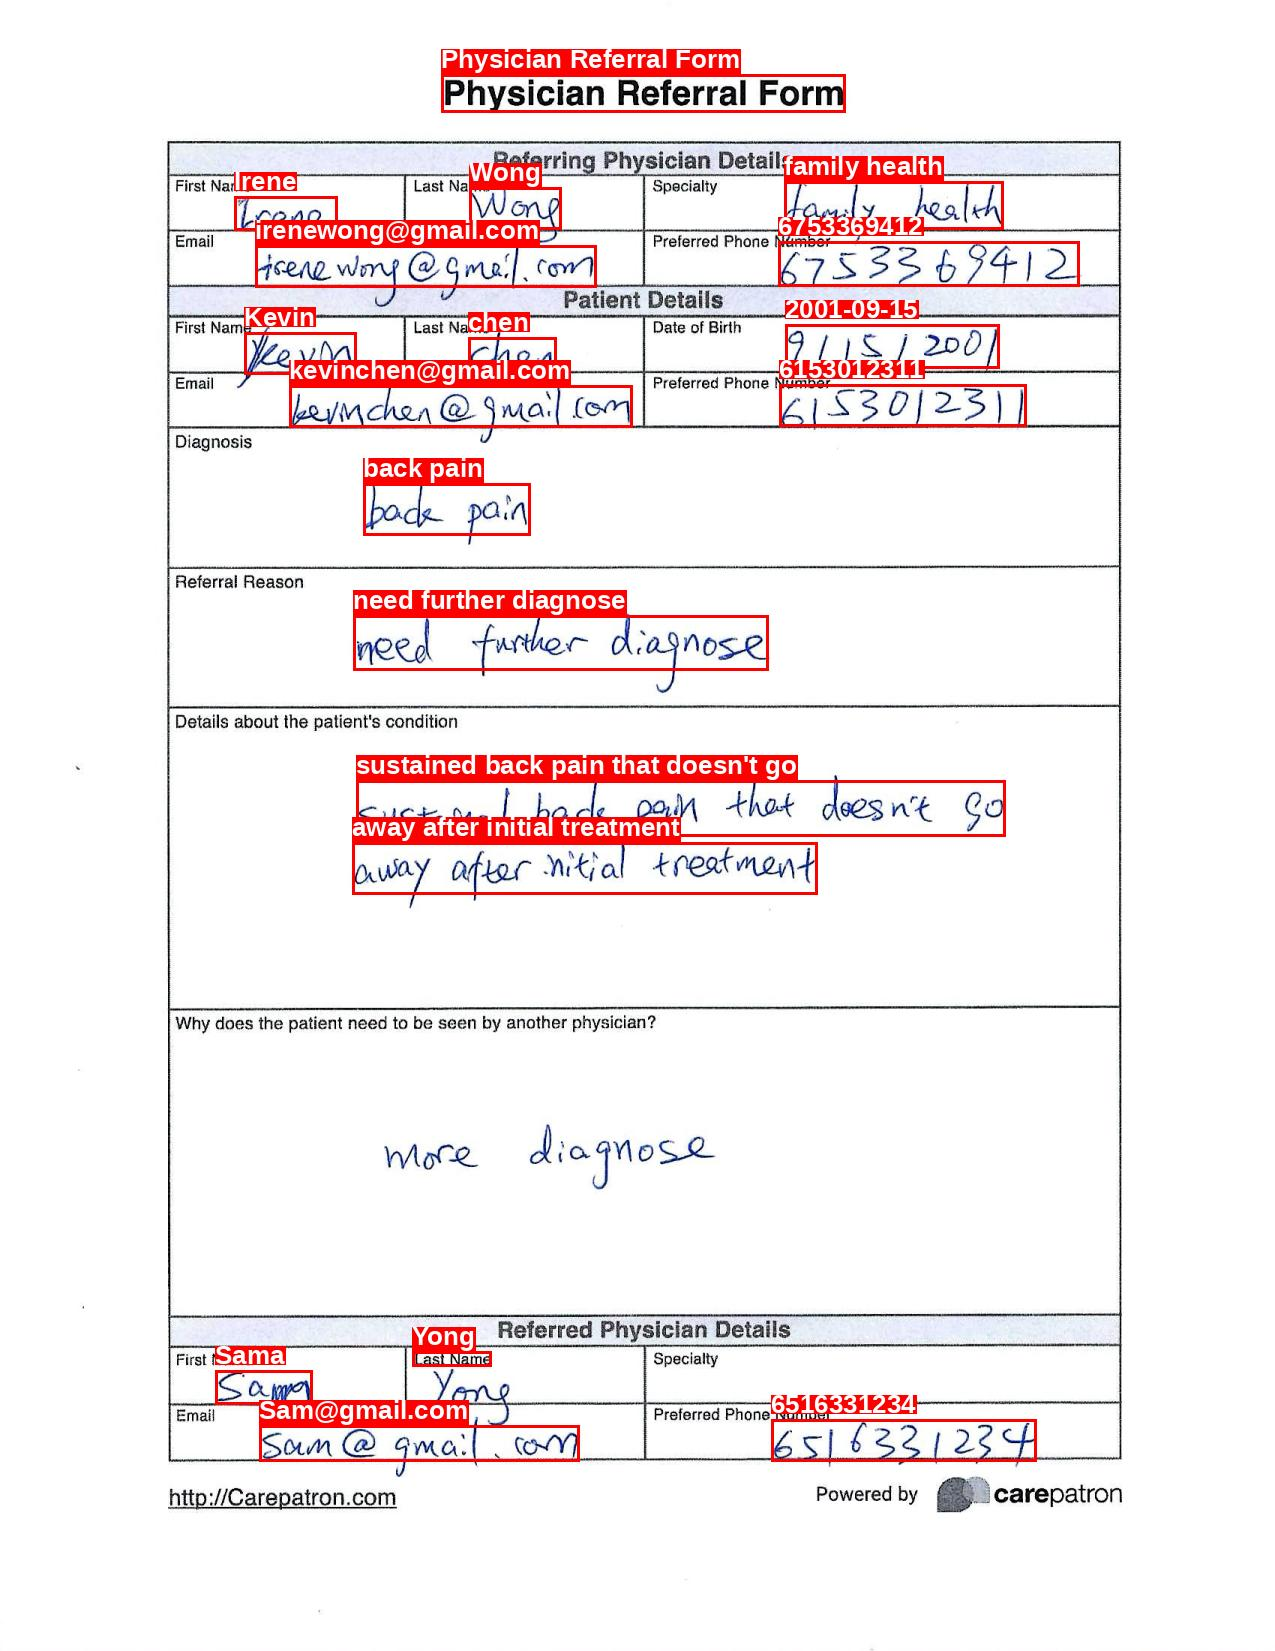

In [19]:
custom_bboxes = collect_bboxes(custom_payload)
print(f"Found {len(custom_bboxes)} grounded boxes in the custom-schema payload")

if custom_bboxes:
    render_bboxes(custom_bboxes, pdf_pages)
else:
    print("No bboxes found. Inspect custom_payload above.")


In [20]:
# Readable summary of the same fields (run the cell above first)
if custom_bboxes:
    display(show_extracted(custom_bboxes))


Field,Value,Confidence
patient.givenName,Kevin,hi
patient.familyName,chen,hi
patient.dateOfBirth,2001-09-15,hi
patient.email,kevinchen@gmail.com,med
patient.phoneNumber,6153012311,hi
referringProvider.givenName,Irene,hi
referringProvider.familyName,Wong,hi
referringProvider.specialty,family health,hi
referringProvider.email,irenewong@gmail.com,med
referringProvider.phoneNumber,6753369412,hi


---
## 📋 8. Summary

Same document, two surfaces. Everything that changes, side by side:

| | Requests (VLM-1) | Executions (Orion-2) |
|---|---|---|
| **Call** | `client.document.generate` | `client.agent.execute` |
| **Model** | `vlm-1` | `vlmrun-orion-2:pro` |
| **Input** | local file path | uploaded `file_id` (Files API) |
| **Config** | `domain="healthcare.patient-referral"` | skill: `grounded-document-extraction` |
| **Grounding & confidence** | call flags: `config={"grounding": True, "confidence": True}` | baked into the skill |
| **Wait** | `predictions.wait` | `executions.wait` |
| **Result** | `.response` | `.response` |
| **Custom schema** | custom domain or `json_schema` | `json_schema` on `AgentExecutionConfig` (Section 7) |

**The key points:**

1. The core swap is one function: `document.generate` becomes `agent.execute`, and `predictions.wait` becomes `executions.wait`.
2. Documents move from local paths to uploaded `file_id`s (`client.files.upload`).
3. Domains give way to skills, and grounding moves into the skill, so the execute call stays minimal.
4. The grounded field structure is the same on both sides, so your downstream code carries over.
